In [53]:
!pip install sentence-transformers scikit-learn matplotlib pandas numpy


In [54]:
# Imports
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt


In [55]:
# Replace with your actual CSV file name
file_path = "/content/Person1_Venture_Challenges (2).csv"

# Load CSV, using 'python' engine for better handling of malformed lines
# and specifying escapechar if backslashes are used for escaping.
df = pd.read_csv(file_path, engine='python', escapechar='\\', on_bad_lines='skip')

# Inspect first few rows
df.head()

,person1_venture_challenges
0,scale up
1,mi reto capacitarme mas y mas para aprender
2,scale up
3,scale up
4,"Currently the product is made at lab scale, it..."


In [56]:
# Extract all non-empty challenge statements
texts = df["person1_venture_challenges"].dropna().astype(str).tolist()

print("Total challenge entries:", len(texts))
print("Sample entry:\n", texts[0])


Total challenge entries: 2190
Sample entry:
 scale up


In [57]:
internal_anchors = [
    "This is an INTERNAL venture challenge: issues within the company such as lack of team coordination.",
    "This is an INTERNAL venture challenge: problems with product development, design, and workflow.",
    "This is an INTERNAL venture challenge: internal management inefficiency and skill shortages.",
    "This is an INTERNAL venture challenge: leadership and training issues among employees.",
    "This is an INTERNAL venture challenge: lack of innovation and poor technical capabilities.",
    "This is an INTERNAL venture challenge: organization and process breakdowns."
]

external_anchors = [
    "This is an EXTERNAL venture challenge: lack of funding, customers, or market demand.",
    "This is an EXTERNAL venture challenge: external forces like government regulations and economic barriers.",
    "This is an EXTERNAL venture challenge: challenges in reaching customers or competing in the market.",
    "This is an EXTERNAL venture challenge: difficulties caused by supply chain and external dependencies.",
    "This is an EXTERNAL venture challenge: investor rejection and market visibility issues.",
    "This is an EXTERNAL venture challenge: global market conditions affecting performance."
]


In [58]:
prompted_texts = [
    f"Classify this as an INTERNAL or EXTERNAL venture challenge: {t}"
    for t in texts
]
challenge_vecs = model.encode(prompted_texts)


In [59]:
# Load multilingual sentence embedding model
model = SentenceTransformer('xlm-roberta-base')
prompted_texts = [f"This is a venture challenge: {t}" for t in texts]
challenge_vecs = model.encode(prompted_texts)
internal_anchors = [f"This is an INTERNAL venture challenge: {p}" for p in internal_anchors]
external_anchors = [f"This is an EXTERNAL venture challenge: {p}" for p in external_anchors]



In [60]:
# Convert anchors to embeddings
int_vecs = model.encode(internal_anchors)
ext_vecs = model.encode(external_anchors)

# Calculate mean (centroid) for each group
int_center = np.mean(int_vecs, axis=0)
ext_center = np.mean(ext_vecs, axis=0)

print("Anchor centroids created successfully.")


Anchor centroids created successfully.


In [61]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Compute similarities
S_internal = cosine_similarity(challenge_vecs, int_center.reshape(1, -1))
S_external = cosine_similarity(challenge_vecs, ext_center.reshape(1, -1))

# Calculate IES (Internal-External Score) as a normalized value between 0 and 1
# A higher IES means more external. This is calculated as S_external / (S_internal + S_external)
# This is consistent with the type of values expected by the label_ies function (0 to 1 range).
df["IES"] = S_external / (S_internal + S_external)

# The binary classification into "External" or "Internal" (no hybrid) will be handled by the label_ies function,
# so removing the direct assignment here to avoid redundancy and ensure label_ies is the source of "Category".
# df["Category"] = np.where(S_external > S_internal, "External", "Internal")

# Optional: similarity gap as confidence measure. Keep this as it might be useful.
df["Confidence"] = np.abs(S_external - S_internal)

In [62]:
# Assign 'Internal' or 'External' based on the comparison of S_external and S_internal
# This replaces the five-level categorization with the requested two-level one.
# The IES column will remain in the DataFrame for potential future use but won't be displayed in this head preview.
df["Category"] = np.where(S_external > S_internal, "External", "Internal").flatten()

df[["person1_venture_challenges", "Category"]].head(10)

,person1_venture_challenges,Category
0,scale up,Internal
1,mi reto capacitarme mas y mas para aprender,Internal
2,scale up,Internal
3,scale up,Internal
4,"Currently the product is made at lab scale, it...",External
5,"CÃ³mo crecer, como estar legalmente, si debo o...",External
6,Strategy Formulation / Strategic Planning and...,Internal
7,Strategy Formulation / Strategic Planning and...,Internal
8,"As of now, I'm encountering several challenges...",External
9,"Currently the product is made at lab scale, it...",External


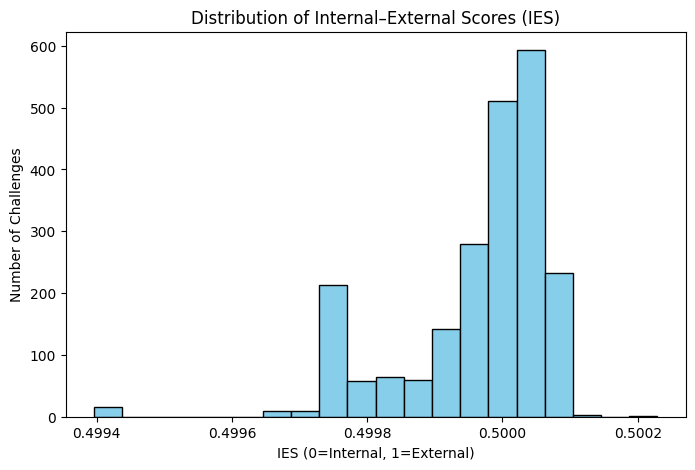

In [63]:
plt.figure(figsize=(8,5))
plt.hist(df["IES"], bins=20, color="skyblue", edgecolor="black")
plt.title("Distribution of Internal–External Scores (IES)")
plt.xlabel("IES (0=Internal, 1=External)")
plt.ylabel("Number of Challenges")
plt.show()


In [64]:
df.to_csv("Venture_Challenges_IES_Classified.csv", index=False)
print("Output saved as Venture_Challenges_IES_Classified.csv")


Output saved as Venture_Challenges_IES_Classified.csv


/tmp/ipython-input-1802370137.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')


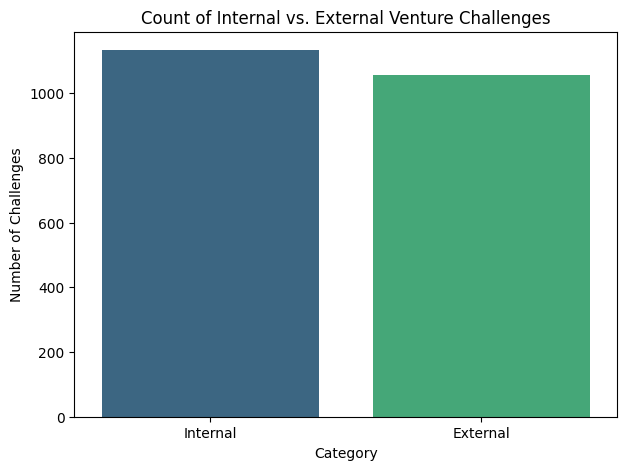

In [66]:
import seaborn as sns

category_counts = df['Category'].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.title('Count of Internal vs. External Venture Challenges')
plt.xlabel('Category')
plt.ylabel('Number of Challenges')
plt.show()